In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Data paths (pointing to the parent directory's data folder)
DATA_DIR = '../data'

# 1. Load Teams Data (Men's)
m_teams = pd.read_csv(f'{DATA_DIR}/MTeams.csv')
m_spellings = pd.read_csv(f'{DATA_DIR}/MTeamSpellings.csv', encoding='cp1252')

# 2. Load Compact Results Data
m_reg_results = pd.read_csv(f'{DATA_DIR}/MRegularSeasonCompactResults.csv')
m_tourney_results = pd.read_csv(f'{DATA_DIR}/MNCAATourneyCompactResults.csv')

print(f"MTeams shape: {m_teams.shape}")
print(f"MRegularSeasonCompactResults shape: {m_reg_results.shape}")
m_teams.head()

MTeams shape: (381, 4)
MRegularSeasonCompactResults shape: (198079, 8)


,TeamID,TeamName,FirstD1Season,LastD1Season
0,1101,Abilene Chr,2014,2026
1,1102,Air Force,1985,2026
2,1103,Akron,1985,2026
3,1104,Alabama,1985,2026
4,1105,Alabama A&M,2000,2026


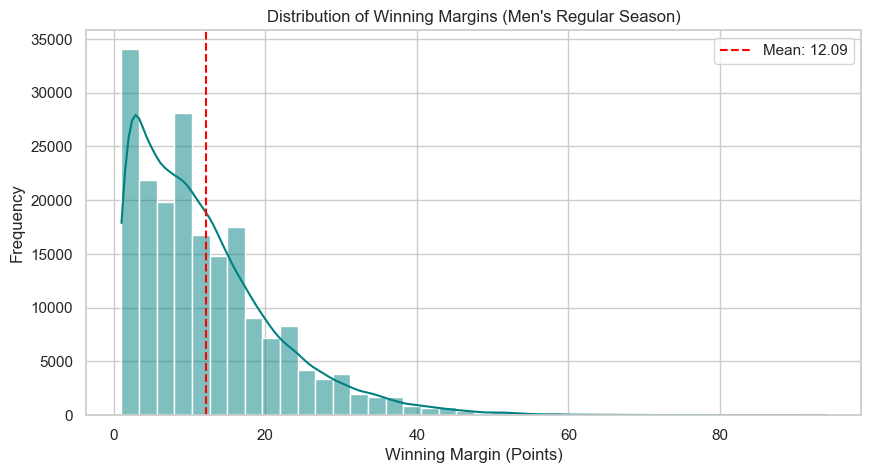

In [3]:
# Calculate score margins
m_reg_results['ScoreMargin'] = m_reg_results['WScore'] - m_reg_results['LScore']

# Plot the distribution of winning margins
plt.figure(figsize=(10, 5))
sns.histplot(m_reg_results['ScoreMargin'], bins=40, kde=True, color='teal')
plt.title('Distribution of Winning Margins (Men\'s Regular Season)')
plt.xlabel('Winning Margin (Points)')
plt.ylabel('Frequency')
plt.axvline(m_reg_results['ScoreMargin'].mean(), color='red', linestyle='--', label=f"Mean: {m_reg_results['ScoreMargin'].mean():.2f}")
plt.legend()
plt.show()

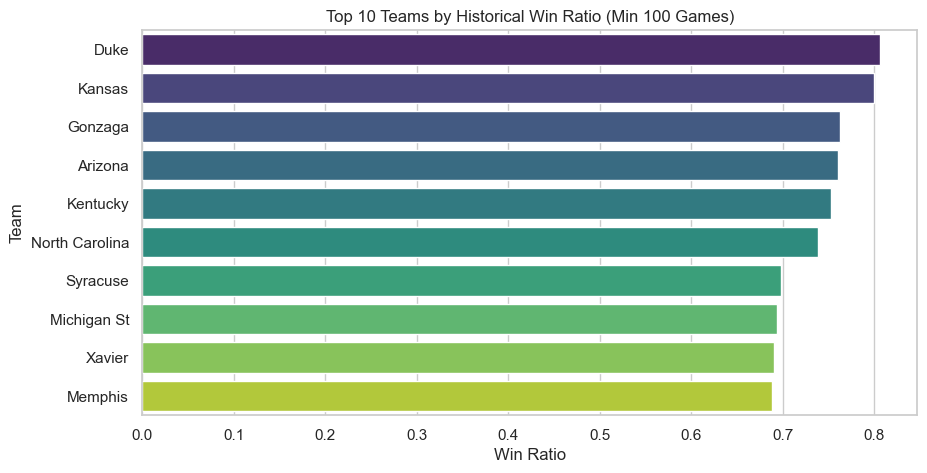

In [4]:
# Count wins by team
wins = m_reg_results['WTeamID'].value_counts().reset_index()
wins.columns = ['TeamID', 'Wins']

# Count losses by team
losses = m_reg_results['LTeamID'].value_counts().reset_index()
losses.columns = ['TeamID', 'Losses']

# Merge to get win/loss record
win_loss = pd.merge(wins, losses, on='TeamID', how='outer').fillna(0)
win_loss['TotalGames'] = win_loss['Wins'] + win_loss['Losses']
win_loss['WinRatio'] = win_loss['Wins'] / win_loss['TotalGames']

# Merge with team names to make it readable
top_teams = pd.merge(win_loss, m_teams[['TeamID', 'TeamName']], on='TeamID')
top_teams = top_teams[top_teams['TotalGames'] >= 100] # Filter out teams with too few games
top_teams = top_teams.sort_values(by='WinRatio', ascending=False).head(10)

# Visualize top 10 historical teams
plt.figure(figsize=(10, 5))
sns.barplot(x='WinRatio', y='TeamName', data=top_teams, hue='TeamName', palette='viridis', legend=False)
plt.title('Top 10 Teams by Historical Win Ratio (Min 100 Games)')
plt.xlabel('Win Ratio')
plt.ylabel('Team')
plt.show()

/var/folders/cr/4c9jg_px6xnb841_l3_k44x40000gn/T/ipykernel_99576/2473646902.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=m_reg_results, x='WLoc', palette='Set2')


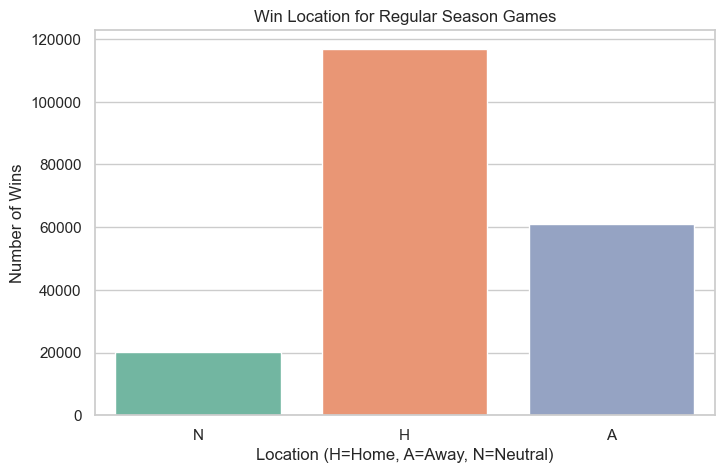

Home Win Percentage (excluding neutral): 65.76%


In [5]:
# Investigate Home-Court Advantage
plt.figure(figsize=(8, 5))
sns.countplot(data=m_reg_results, x='WLoc', palette='Set2')
plt.title('Win Location for Regular Season Games')
plt.xlabel('Location (H=Home, A=Away, N=Neutral)')
plt.ylabel('Number of Wins')
plt.show()

# Proportion of Home Court Wins
home_wins = m_reg_results[m_reg_results['WLoc'] == 'H'].shape[0]
total_non_neutral = m_reg_results[m_reg_results['WLoc'].isin(['H', 'A'])].shape[0]
if total_non_neutral > 0:
    print(f"Home Win Percentage (excluding neutral): {home_wins / total_non_neutral * 100:.2f}%")


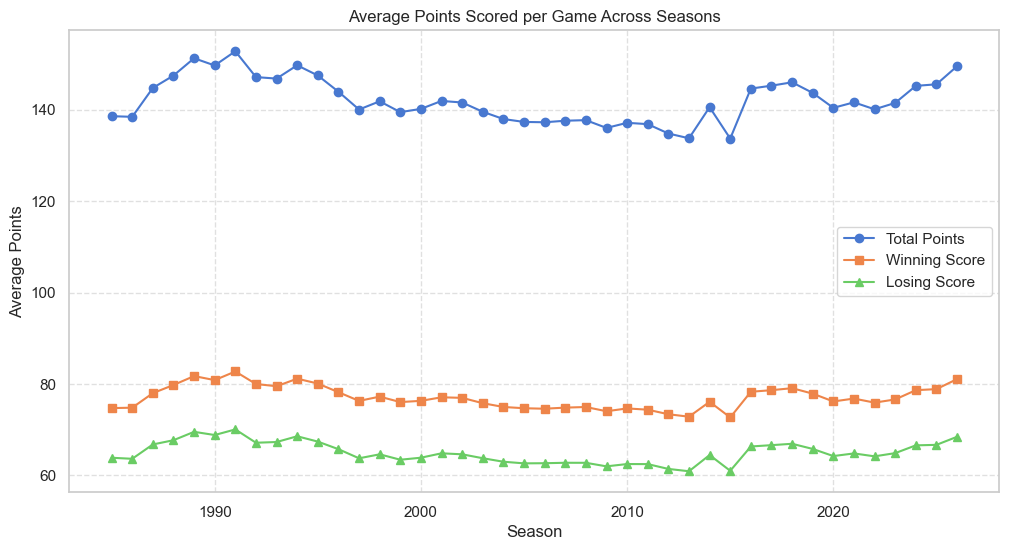

In [6]:
# Analyze Scoring Trends Over Time
m_reg_results['TotalPoints'] = m_reg_results['WScore'] + m_reg_results['LScore']
season_scoring = m_reg_results.groupby('Season')[['WScore', 'LScore', 'TotalPoints']].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(season_scoring['Season'], season_scoring['TotalPoints'], marker='o', label='Total Points')
plt.plot(season_scoring['Season'], season_scoring['WScore'], marker='s', label='Winning Score')
plt.plot(season_scoring['Season'], season_scoring['LScore'], marker='^', label='Losing Score')
plt.title('Average Points Scored per Game Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Points')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [7]:
# Load Tournament Seeds
m_seeds = pd.read_csv(f'{DATA_DIR}/MNCAATourneySeeds.csv')
m_seeds['SeedNum'] = m_seeds['Seed'].apply(lambda x: int(x[1:3])) # Extract numeric part of seed

print(f"MSeeds shape: {m_seeds.shape}")
m_seeds.head()


MSeeds shape: (2626, 4)


,Season,Seed,TeamID,SeedNum
0,1985,W01,1207,1
1,1985,W02,1210,2
2,1985,W03,1228,3
3,1985,W04,1260,4
4,1985,W05,1374,5


Overall Tournament Upset Percentage: 27.31%


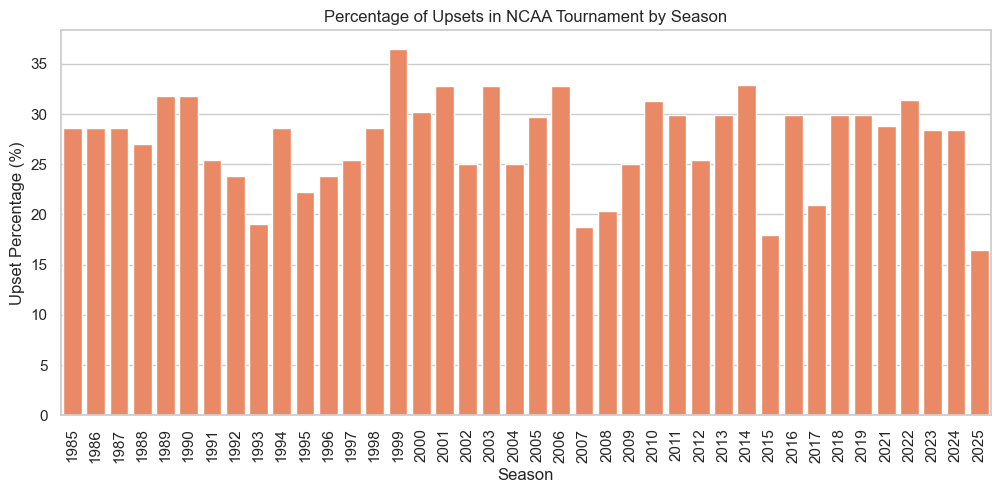

In [8]:
# Merge Seeds with Tournament Results
# Winning Team Seeds
tourney_seeds_w = m_tourney_results.merge(m_seeds, left_on=['Season', 'WTeamID'], right_on=['Season', 'TeamID'], how='left')
tourney_seeds_w.rename(columns={'SeedNum': 'WSeedNum'}, inplace=True)
tourney_seeds_w.drop(columns=['TeamID', 'Seed'], inplace=True)

# Losing Team Seeds
tourney_seeds_l = tourney_seeds_w.merge(m_seeds, left_on=['Season', 'LTeamID'], right_on=['Season', 'TeamID'], how='left')
tourney_seeds_l.rename(columns={'SeedNum': 'LSeedNum'}, inplace=True)
tourney_seeds_l.drop(columns=['TeamID', 'Seed'], inplace=True)

# Determine Upsets: An upset happens if the winning team has a strictly larger seed number than the losing team
# (e.g., Seed 11 beats Seed 6)
tourney_seeds_l['IsUpset'] = tourney_seeds_l['WSeedNum'] > tourney_seeds_l['LSeedNum']

# Percentage of upsets overall
upset_percentage = tourney_seeds_l['IsUpset'].mean() * 100
print(f"Overall Tournament Upset Percentage: {upset_percentage:.2f}%")

# Plot Upsets by Season
season_upsets = tourney_seeds_l.groupby('Season')['IsUpset'].mean().reset_index()
season_upsets['IsUpset'] = season_upsets['IsUpset'] * 100

plt.figure(figsize=(12, 5))
sns.barplot(data=season_upsets, x='Season', y='IsUpset', color='coral')
plt.title('Percentage of Upsets in NCAA Tournament by Season')
plt.xlabel('Season')
plt.ylabel('Upset Percentage (%)')
plt.xticks(rotation=90)
plt.show()


Detailed Results shape: (124031, 34)


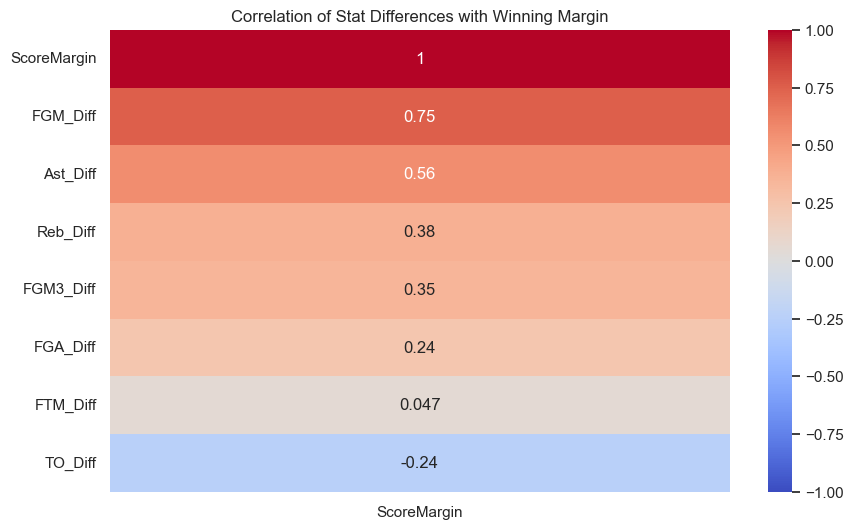

In [9]:
# Load Detailed Results for more in-depth stats (like rebounds, assists, turnovers)
import os
detailed_results_path = f'{DATA_DIR}/MRegularSeasonDetailedResults.csv'
if os.path.exists(detailed_results_path):
    detailed_results = pd.read_csv(detailed_results_path)
    print(f"Detailed Results shape: {detailed_results.shape}")
    
    # Analyze the difference in specific stats between Winners and Losers
    # E.g., Rebounds, Assists, Turnovers
    stats_diff = pd.DataFrame()
    stats_diff['FGM_Diff'] = detailed_results['WFGM'] - detailed_results['LFGM']
    stats_diff['FGA_Diff'] = detailed_results['WFGA'] - detailed_results['LFGA']
    stats_diff['FGM3_Diff'] = detailed_results['WFGM3'] - detailed_results['LFGM3']
    stats_diff['FTM_Diff'] = detailed_results['WFTM'] - detailed_results['LFTM']
    stats_diff['Reb_Diff'] = (detailed_results['WOR'] + detailed_results['WDR']) - (detailed_results['LOR'] + detailed_results['LDR'])
    stats_diff['Ast_Diff'] = detailed_results['WAst'] - detailed_results['LAst']
    stats_diff['TO_Diff'] = detailed_results['WTO'] - detailed_results['LTO']
    stats_diff['ScoreMargin'] = detailed_results['WScore'] - detailed_results['LScore']

    correlation_matrix = stats_diff.corr()

    # Plot correlations with Score Margin
    plt.figure(figsize=(10, 6))
    score_margin_corr = correlation_matrix[['ScoreMargin']].sort_values(by='ScoreMargin', ascending=False)
    sns.heatmap(score_margin_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlation of Stat Differences with Winning Margin')
    plt.show()
else:
    print("Detailed Regular Season Results file not found.")
